# 05 — Policy Simulation

Use the trained ML model for counterfactual predictions:
- H4: Convert 30% of emergency admissions to elective at high-ER hospitals
- H5: Standardize protocols — reduce conservative treatment to ≤20%

Quantify: bed-days saved, beds freed, cost saved, deaths preventable.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import lightgbm as lgb

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

OUTPUT_DIR = Path("../outputs")
PLOT_DIR = OUTPUT_DIR / "plots"
METRICS_DIR = OUTPUT_DIR / "metrics"

kidney = pd.read_parquet(OUTPUT_DIR / "kidney_sih.parquet")

# Load feature names and model
with open(OUTPUT_DIR / "feature_names.json") as f:
    FEATURE_COLS = json.load(f)

model = lgb.Booster(model_file=str(OUTPUT_DIR / "lgbm_model.txt"))
print(f"Model loaded. Features: {FEATURE_COLS}")

Model loaded. Features: ['is_emergency', 'is_male', 'has_new_proc', 'has_litho', 'age', 'hospital_volume', 'hospital_er_rate', 'hospital_new_proc_rate', 'hospital_litho_rate', 'hospital_conservative_rate']


## Reconstruct Features

Rebuild the same features used in training so we can run counterfactuals.

In [2]:
NEW_PROC = "0409010596"
LITHO_PROC = "0409010146"

kidney["PROC_REA"] = kidney["PROC_REA"].astype(str).str.strip()
# SEXO and CAR_INT are stored as strings in the parquet
kidney["is_emergency"] = (kidney["CAR_INT"].astype(str) == "02").astype(int)
kidney["is_male"] = (kidney["SEXO"].astype(str) == "1").astype(int)
kidney["has_new_proc"] = (kidney["PROC_REA"] == NEW_PROC).astype(int)
kidney["has_litho"] = (kidney["PROC_REA"] == LITHO_PROC).astype(int)
kidney["age"] = pd.to_numeric(kidney["IDADE"], errors="coerce").fillna(0)
kidney["is_conservative"] = ((kidney["has_new_proc"] == 0) & (kidney["has_litho"] == 0)).astype(int)

hospital_stats = kidney.groupby("CNES").agg(
    hospital_volume=("DIAG_PRINC", "count"),
    hospital_er_rate=("is_emergency", "mean"),
    hospital_new_proc_rate=("has_new_proc", "mean"),
    hospital_litho_rate=("has_litho", "mean"),
    hospital_conservative_rate=("is_conservative", "mean"),
).reset_index()

kidney = kidney.merge(hospital_stats, on="CNES", how="left", suffixes=("", "_dup"))

# Use most recent year for simulation
recent = kidney[kidney["year"] >= 2023].copy()
print(f"Simulation cohort: {len(recent):,} patients (2023+)")

Simulation cohort: 88,109 patients (2023+)


## Intervention 1: Elective Urology Pathway

At hospitals with ER rate >50%, convert 30% of emergency admissions to scheduled elective.

In [3]:
X_baseline = recent[FEATURE_COLS].copy()
baseline_pred = model.predict(X_baseline)

# Intervention: flip 30% of ER admissions at high-ER hospitals
X_elective = X_baseline.copy()
high_er_mask = (X_elective["hospital_er_rate"] > 0.5) & (X_elective["is_emergency"] == 1)
flip_idx = X_elective[high_er_mask].sample(frac=0.3, random_state=42).index
X_elective.loc[flip_idx, "is_emergency"] = 0

elective_pred = model.predict(X_elective)

bed_days_saved_elective = (baseline_pred - elective_pred).sum()
beds_freed_elective = bed_days_saved_elective / 365

print(f"Intervention 1 — Elective Pathway")
print(f"  Patients affected: {len(flip_idx):,}")
print(f"  Bed-days saved/year: {bed_days_saved_elective:,.0f}")
print(f"  Beds freed: {beds_freed_elective:.1f}")

Intervention 1 — Elective Pathway
  Patients affected: 11,318
  Bed-days saved/year: 10,011
  Beds freed: 27.4


## Intervention 2: Protocol Standardization

At hospitals with conservative rate >40%, cap it at 20%.

In [4]:
X_protocol = X_baseline.copy()
high_conservative = X_protocol["hospital_conservative_rate"] > 0.4
X_protocol.loc[high_conservative, "hospital_conservative_rate"] = 0.2

protocol_pred = model.predict(X_protocol)

bed_days_saved_protocol = (baseline_pred - protocol_pred).sum()
beds_freed_protocol = bed_days_saved_protocol / 365

print(f"Intervention 2 — Protocol Standardization")
print(f"  Patients affected: {high_conservative.sum():,}")
print(f"  Bed-days saved/year: {bed_days_saved_protocol:,.0f}")
print(f"  Beds freed: {beds_freed_protocol:.1f}")

Intervention 2 — Protocol Standardization
  Patients affected: 75,826
  Bed-days saved/year: 4,551
  Beds freed: 12.5


## Combined Impact

In [5]:
COST_PER_BED_DAY = 466  # R$ SUS average
MORTALITY_RATE = 0.0021  # Kidney stone mortality rate in data
LONG_STAY_THRESHOLD = 7  # days

total_bed_days = bed_days_saved_elective + bed_days_saved_protocol
total_beds = total_bed_days / 365
total_cost_saved = total_bed_days * COST_PER_BED_DAY
deaths_prevented = total_bed_days * MORTALITY_RATE / recent["DIAS_PERM"].mean()

# Long stays eliminated
long_stays_baseline = (baseline_pred > LONG_STAY_THRESHOLD).sum()
X_combined = X_elective.copy()
X_combined.loc[high_conservative, "hospital_conservative_rate"] = 0.2
combined_pred = model.predict(X_combined)
long_stays_after = (combined_pred > LONG_STAY_THRESHOLD).sum()

simulation_results = {
    "intervention_1_elective": {
        "patients_affected": int(len(flip_idx)),
        "bed_days_saved": round(float(bed_days_saved_elective)),
        "beds_freed": round(float(beds_freed_elective), 1),
    },
    "intervention_2_protocol": {
        "patients_affected": int(high_conservative.sum()),
        "bed_days_saved": round(float(bed_days_saved_protocol)),
        "beds_freed": round(float(beds_freed_protocol), 1),
    },
    "combined_impact": {
        "total_bed_days_saved": round(float(total_bed_days)),
        "total_beds_freed": round(float(total_beds), 1),
        "cost_saved_brl": round(float(total_cost_saved)),
        "deaths_prevented": round(float(deaths_prevented), 1),
        "long_stays_eliminated": int(long_stays_baseline - long_stays_after),
    },
}

with open(METRICS_DIR / "simulation_results.json", "w") as f:
    json.dump(simulation_results, f, indent=2)

print("\n=== Combined Impact (per year) ===")
for k, v in simulation_results["combined_impact"].items():
    print(f"  {k}: {v:,}" if isinstance(v, int) else f"  {k}: {v}")


=== Combined Impact (per year) ===
  total_bed_days_saved: 14,562
  total_beds_freed: 39.9
  cost_saved_brl: 6,785,769
  deaths_prevented: 13.9
  long_stays_eliminated: 119


## City-Level Savings Breakdown

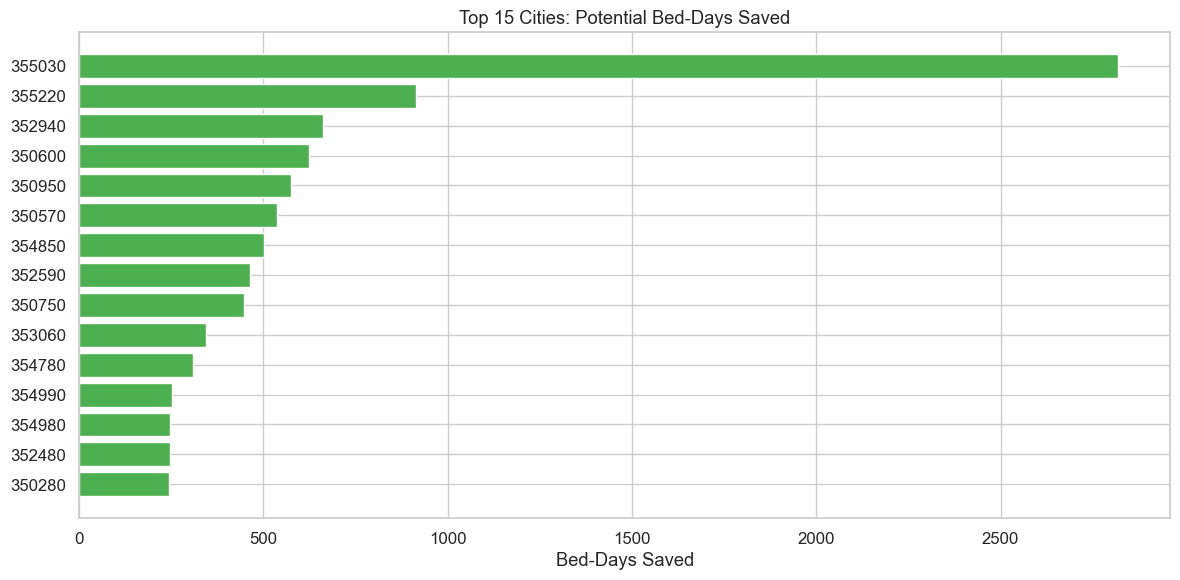

Simulation complete. Results saved to outputs/metrics/simulation_results.json


In [6]:
recent["baseline_pred"] = baseline_pred
recent["combined_pred"] = combined_pred
recent["savings"] = recent["baseline_pred"] - recent["combined_pred"]

city_savings = recent.groupby("MUNIC_MOV").agg(
    total_savings=("savings", "sum"),
    patient_count=("savings", "count"),
    er_rate=("is_emergency", "mean"),
    conservative_rate=("is_conservative", "mean"),
).sort_values("total_savings", ascending=False)

top_cities = city_savings.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top_cities)), top_cities["total_savings"], color="#4CAF50")
ax.set_yticks(range(len(top_cities)))
ax.set_yticklabels(top_cities.index)
ax.set_title("Top 15 Cities: Potential Bed-Days Saved")
ax.set_xlabel("Bed-Days Saved")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(PLOT_DIR / "05_city_savings.png", dpi=150, bbox_inches="tight")
plt.show()

print("Simulation complete. Results saved to outputs/metrics/simulation_results.json")